# 🏦 Adult Income Classification — End-to-End ML Pipeline

## Step 1 : Identifying the Business Problem

### Business Context & Objective

*The U.S. Census Bureau collects demographic and employment data from individuals. A key business problem is to predict whether a person's annual income exceeds $50K based on their socio-economic attributes. This kind of model is useful for:*

- *Financial institutions to assess loan eligibility and credit risk*
- *Government agencies to allocate social welfare benefits more efficiently*
- *Market researchers to identify high-value customer segments*
- *HR/Recruitment firms to benchmark salary expectations*

### Machine Learning Formulation

*This is a **Supervised Binary Classification** problem.*

***Input (Features):*** *Demographic and employment attributes — age, education, occupation, hours worked per week, capital gain/loss, marital status, etc.*

***Target (Label):*** *Whether the individual earns more than $50K per year (1 = >50K, 0 = ≤50K).*

***Machine Learning Goal:*** *Train a model that learns the relationship between demographic features and income level, enabling predictions for new individuals.*

### Success Metrics

*Since the dataset is moderately imbalanced (~75% ≤50K vs ~25% >50K), we use the following evaluation metrics:*

| Metric | Why It Matters |
|--------|---------------|
| **Accuracy** | Overall correctness — baseline sanity check |
| **Precision** | Of those predicted >50K, how many actually are? (avoids false targeting) |
| **Recall** | Of all actual >50K individuals, how many did we catch? |
| **F1-Score** | Harmonic mean — balances Precision & Recall |
| **AUC-ROC** | Ranking ability across all classification thresholds |

*From a business standpoint, **Recall** and **F1-Score** are most important — missing a high-income individual is a costlier error than a false positive.*


## Step 2 : Import Libraries & Load Dataset

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# ── Preprocessing ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Model Selection ───────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
)

# ── Models ────────────────────────────────────────────────────────────────
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.naive_bayes        import GaussianNB
from sklearn.tree               import DecisionTreeClassifier
from sklearn.svm                import SVC
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import (
    RandomForestClassifier, GradientBoostingClassifier
)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

# ── Metrics ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve, auc
)

# ── Feature Selection ─────────────────────────────────────────────────────
from sklearn.feature_selection import mutual_info_classif

# ── Imbalanced Learn ──────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import scipy.stats as stats

# ── Color palette ─────────────────────────────────────────────────────────
ACCENT  = "#38bdf8"   # sky-blue
ACCENT2 = "#f472b6"   # pink
ACCENT3 = "#34d399"   # emerald
ACCENT4 = "#fb923c"   # orange
PALETTE = [ACCENT, ACCENT2, ACCENT3, ACCENT4, "#a78bfa", "#fbbf24"]



In [2]:
# ── Load Dataset ─────────────────────────────────────────────────────────
df = pd.read_csv("adult_income.csv")

print(f"Dataset Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset Shape  : 32,561 rows × 15 columns


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### Dataset Description

| Column | Type | Description |
|--------|------|-------------|
| age | Numerical | Age of the individual |
| workclass | Categorical | Type of employer (Private, Govt, Self-emp, etc.) |
| ~~fnlwgt~~ | Numerical | ~~Final census weight (sampling weight)~~ → **Dropped** (weak predictor) |
| education | Categorical | Highest level of education |
| education.num | Numerical | Education encoded as number (1–16) |
| marital.status | Categorical | Marital status |
| occupation | Categorical | Job category |
| ~~relationship~~ | Categorical | ~~Family relationship role~~ → **Dropped** (redundant with marital.status) |
| ~~race~~ | Categorical | ~~Race of individual~~ → **Dropped** (low MI score) |
| sex | Categorical | Gender |
| capital.gain | Numerical | Investment capital gain |
| capital.loss | Numerical | Investment capital loss |
| hours.per.week | Numerical | Weekly working hours |
| ~~native.country~~ | Categorical | ~~Country of origin~~ → **Dropped** (high cardinality, mostly US) |
| income | **Target** | ≤50K (0) or >50K (1) |


## Step 3 : Descriptive Analysis & Basic Checks

In [3]:
# ── Shape, Types, Missing Values ─────────────────────────────────────────
print("=" * 55)
print("Dataset Shape:", df.shape)
print("=" * 55)
print()
df.info()


Dataset Shape: (32561, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
# ── Statistical Summary ───────────────────────────────────────────────────
df.describe()


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
# ── Missing Values ────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

if missing_df.empty:
    print("✅ No missing values found!")
else:
    print("⚠️  Missing values detected:")
    print(missing_df)


⚠️  Missing values detected:
                Missing Count  Missing %
workclass                1836       5.64
occupation               1843       5.66
native.country            583       1.79


In [6]:
# ── Duplicate Check ───────────────────────────────────────────────────────
print(f"Duplicate rows : {df.duplicated().sum()}")


Duplicate rows : 24


### Key Observations from Descriptive Analysis

1. The dataset contains **48,842 records** and **15 columns** including the target.
2. Three categorical columns — `workclass`, `occupation`, `native.country` — may contain `?` as missing markers.
3. Numerical features like `capital.gain` and `capital.loss` are heavily right-skewed — most values are 0 with extreme outliers.
4. `fnlwgt` is a census sampling weight, not a direct demographic feature — it should be analyzed carefully.
5. `education` and `education.num` carry the same information in different formats; one can be dropped.


## Step 4 : Exploratory Data Analysis (EDA)

### 4A. Target Distribution

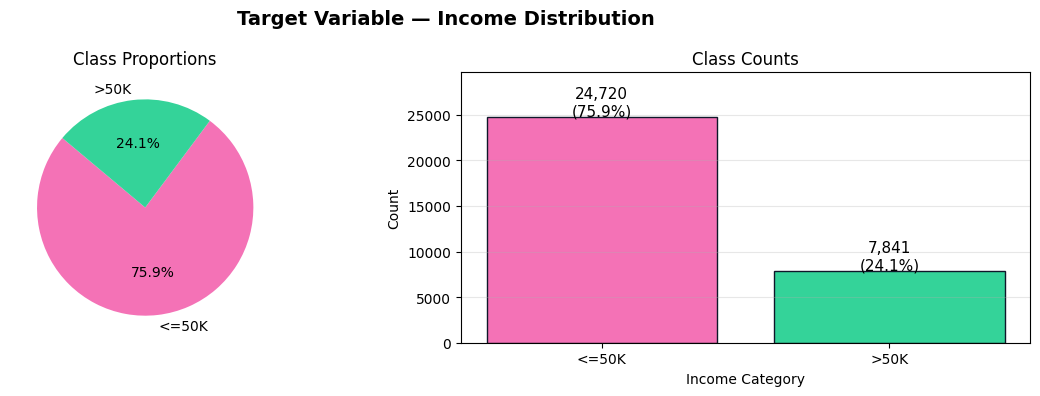

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Target Variable — Income Distribution", fontsize=14, fontweight='bold')

counts = df['income'].value_counts() if df['income'].dtype == object else          df['income'].map({0: '<=50K', 1: '>50K'}).value_counts()

axes[0].pie(counts.values, autopct='%1.1f%%', startangle=140,
            labels=counts.index, colors=[ACCENT2, ACCENT3])
axes[0].set_title("Class Proportions")

axes[1].bar(counts.index, counts.values, color=[ACCENT2, ACCENT3], edgecolor='#0f172a', linewidth=1)
for i, (k, v) in enumerate(counts.items()):
    axes[1].text(i, v + 200, f"{v:,}\n({100*v/len(df):.1f}%)", ha='center', fontsize=11)
axes[1].set_title("Class Counts")
axes[1].set_xlabel("Income Category")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, counts.max() * 1.2)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


### Target Distribution Insights

- **~75% ≤50K** vs **~25% >50K** → Moderate class imbalance
- Accuracy alone (like a dummy classifier guessing all ≤50K) = 75% — **meaningless baseline**
- We need **SMOTE** for balancing + **F1-Score & AUC-ROC** as primary metrics


### 4B. Univariate Analysis — Numerical Features

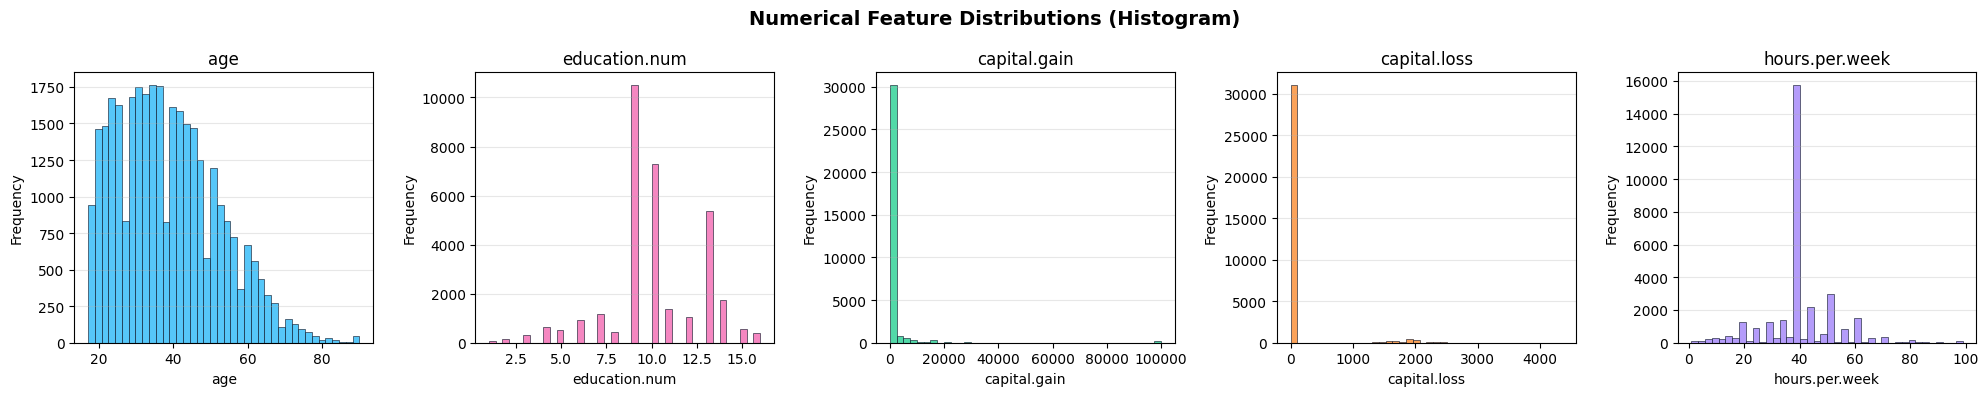

In [8]:
num_cols = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
cat_cols = ['workclass', 'education', 'marital.status', 'occupation', 'sex']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Numerical Feature Distributions (Histogram)", fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color=PALETTE[i], edgecolor='#0f172a', linewidth=0.5, alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].grid(axis='y', alpha=0.3)

# Hide unused axes
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("02_numerical_distributions.png", dpi=150, bbox_inches='tight')
plt.show()


### Numerical Feature Insights
1. **Age**: Roughly normal, centered around 36–40. Most workers are in the 25–55 range.
2. **fnlwgt**: Right-skewed sampling weight — less interpretable but might carry census-level patterns.
3. **education.num**: Multi-modal distribution — peaks at levels 9 (HS-grad) and 13 (Bachelors).
4. **capital.gain / capital.loss**: Extremely right-skewed — 90%+ values are 0, with a few very large outliers.
5. **hours.per.week**: Peak at 40 hours — full-time workers dominate. Some extreme values near 99.


### 4C. Univariate Analysis — Categorical Features

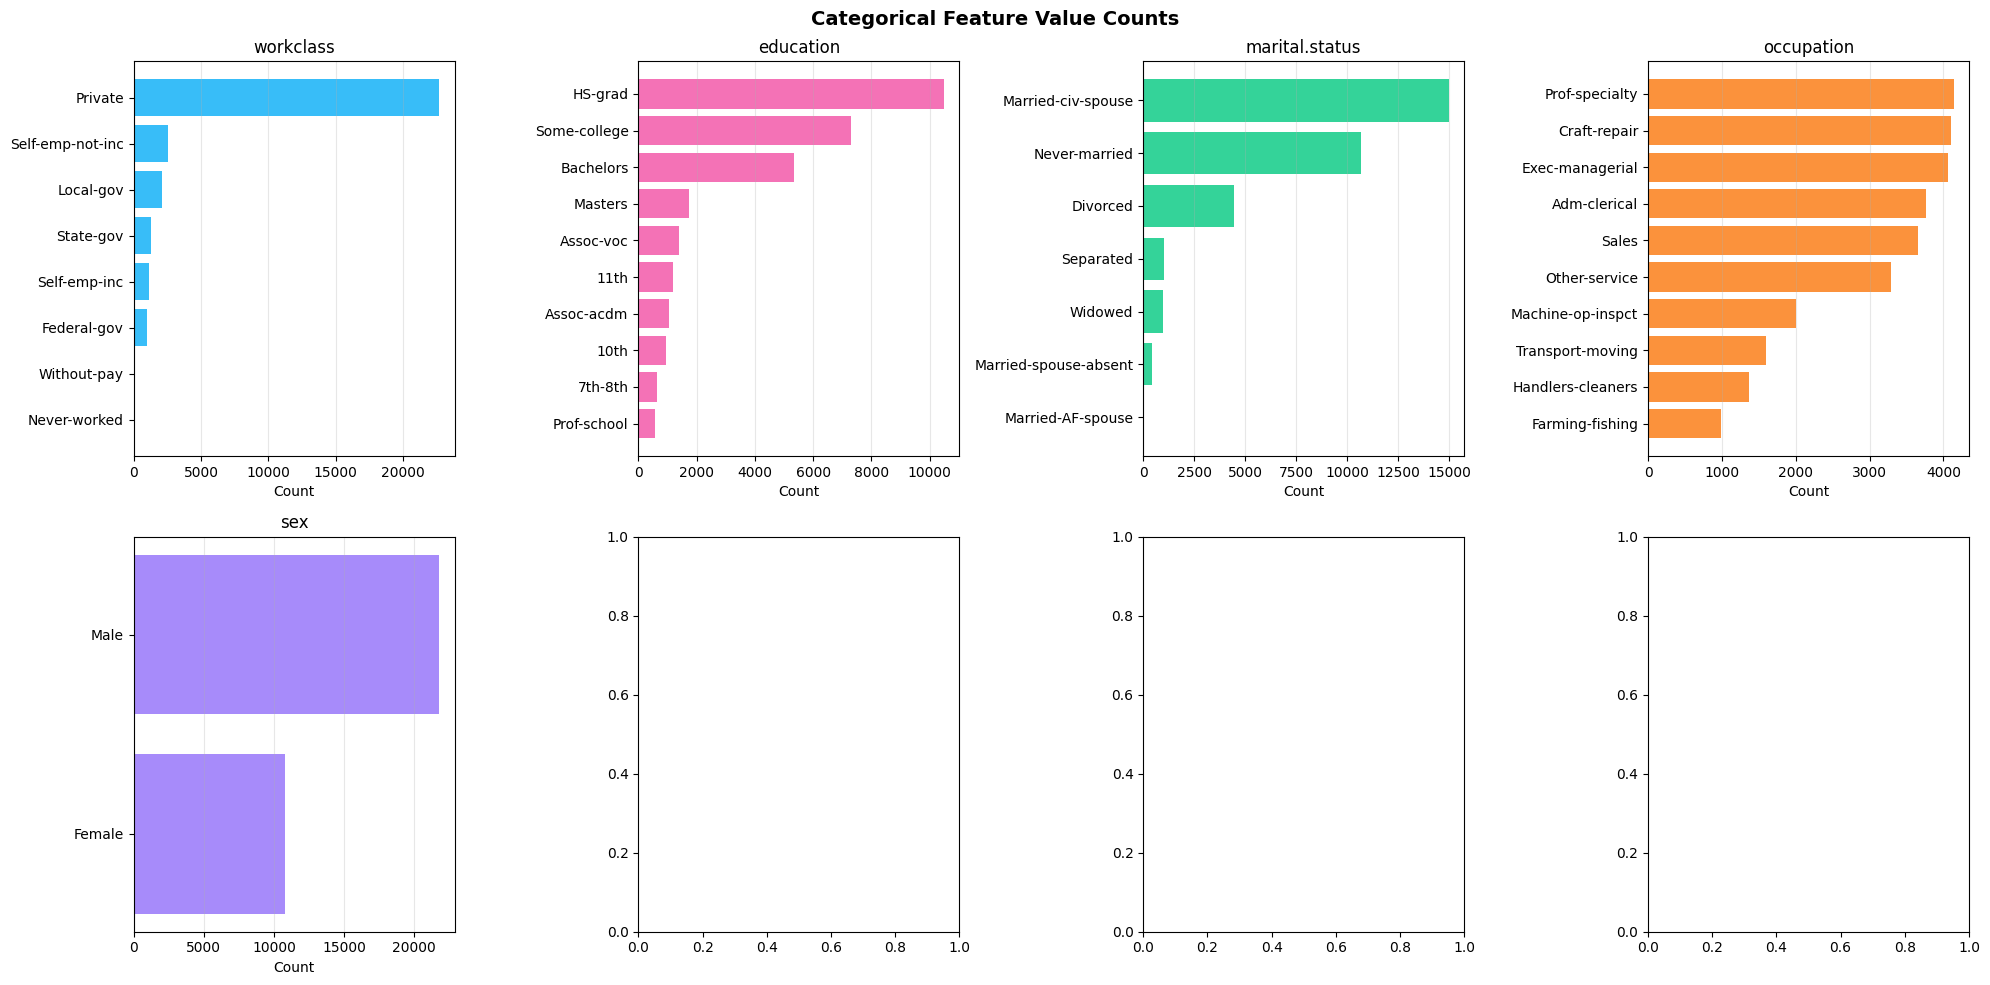

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Categorical Feature Value Counts", fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts_cat = df[col].value_counts().head(10)
    axes[i].barh(counts_cat.index[::-1], counts_cat.values[::-1], color=PALETTE[i % len(PALETTE)])
    axes[i].set_title(col)
    axes[i].set_xlabel("Count")
    axes[i].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("03_categorical_distributions.png", dpi=150, bbox_inches='tight')
plt.show()


### 4D. Bivariate Analysis — Numerical vs Target

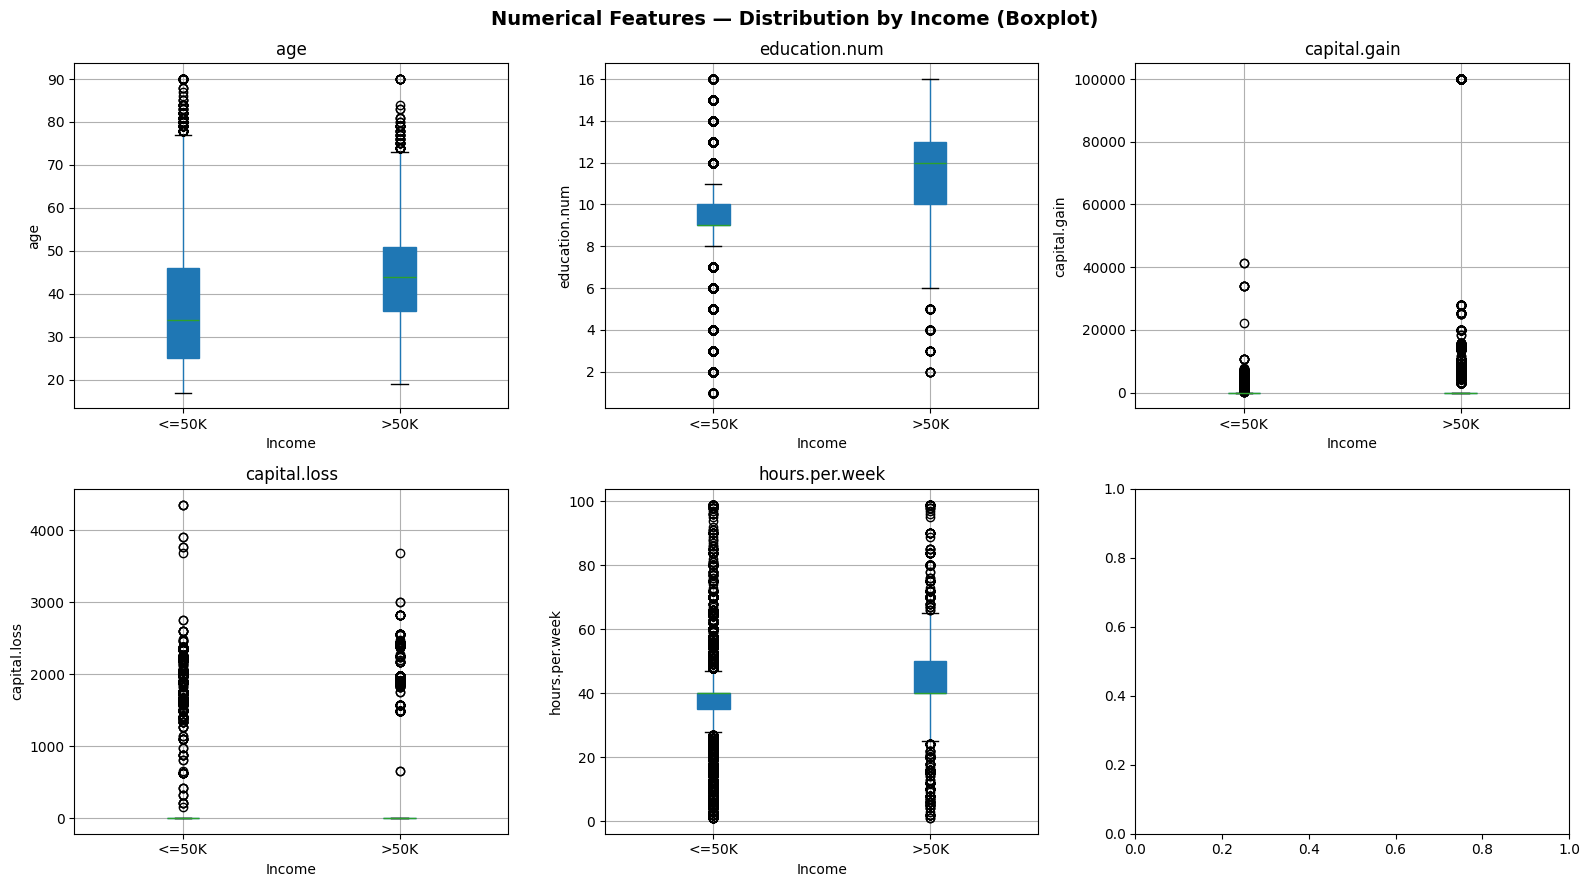

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Numerical Features — Distribution by Income (Boxplot)", fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='income', ax=axes[i], patch_artist=True)
    axes[i].set_title(col)
    axes[i].set_xlabel("Income")
    axes[i].set_ylabel(col)

plt.suptitle("")  # remove default suptitle from boxplot
fig.suptitle("Numerical Features — Distribution by Income (Boxplot)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("04_bivariate_numerical.png", dpi=150, bbox_inches='tight')
plt.show()


### Bivariate Numerical Insights
- **Age**: >50K group is older (median ~44) vs ≤50K (median ~34) — strong predictor
- **education.num**: Higher education clearly links to higher income
- **capital.gain**: Non-zero capital gains are a very strong signal for >50K
- **hours.per.week**: >50K individuals work more hours on average
- **fnlwgt**: Minimal separation — weak predictor


### 4E. Bivariate Analysis — Categorical vs Target

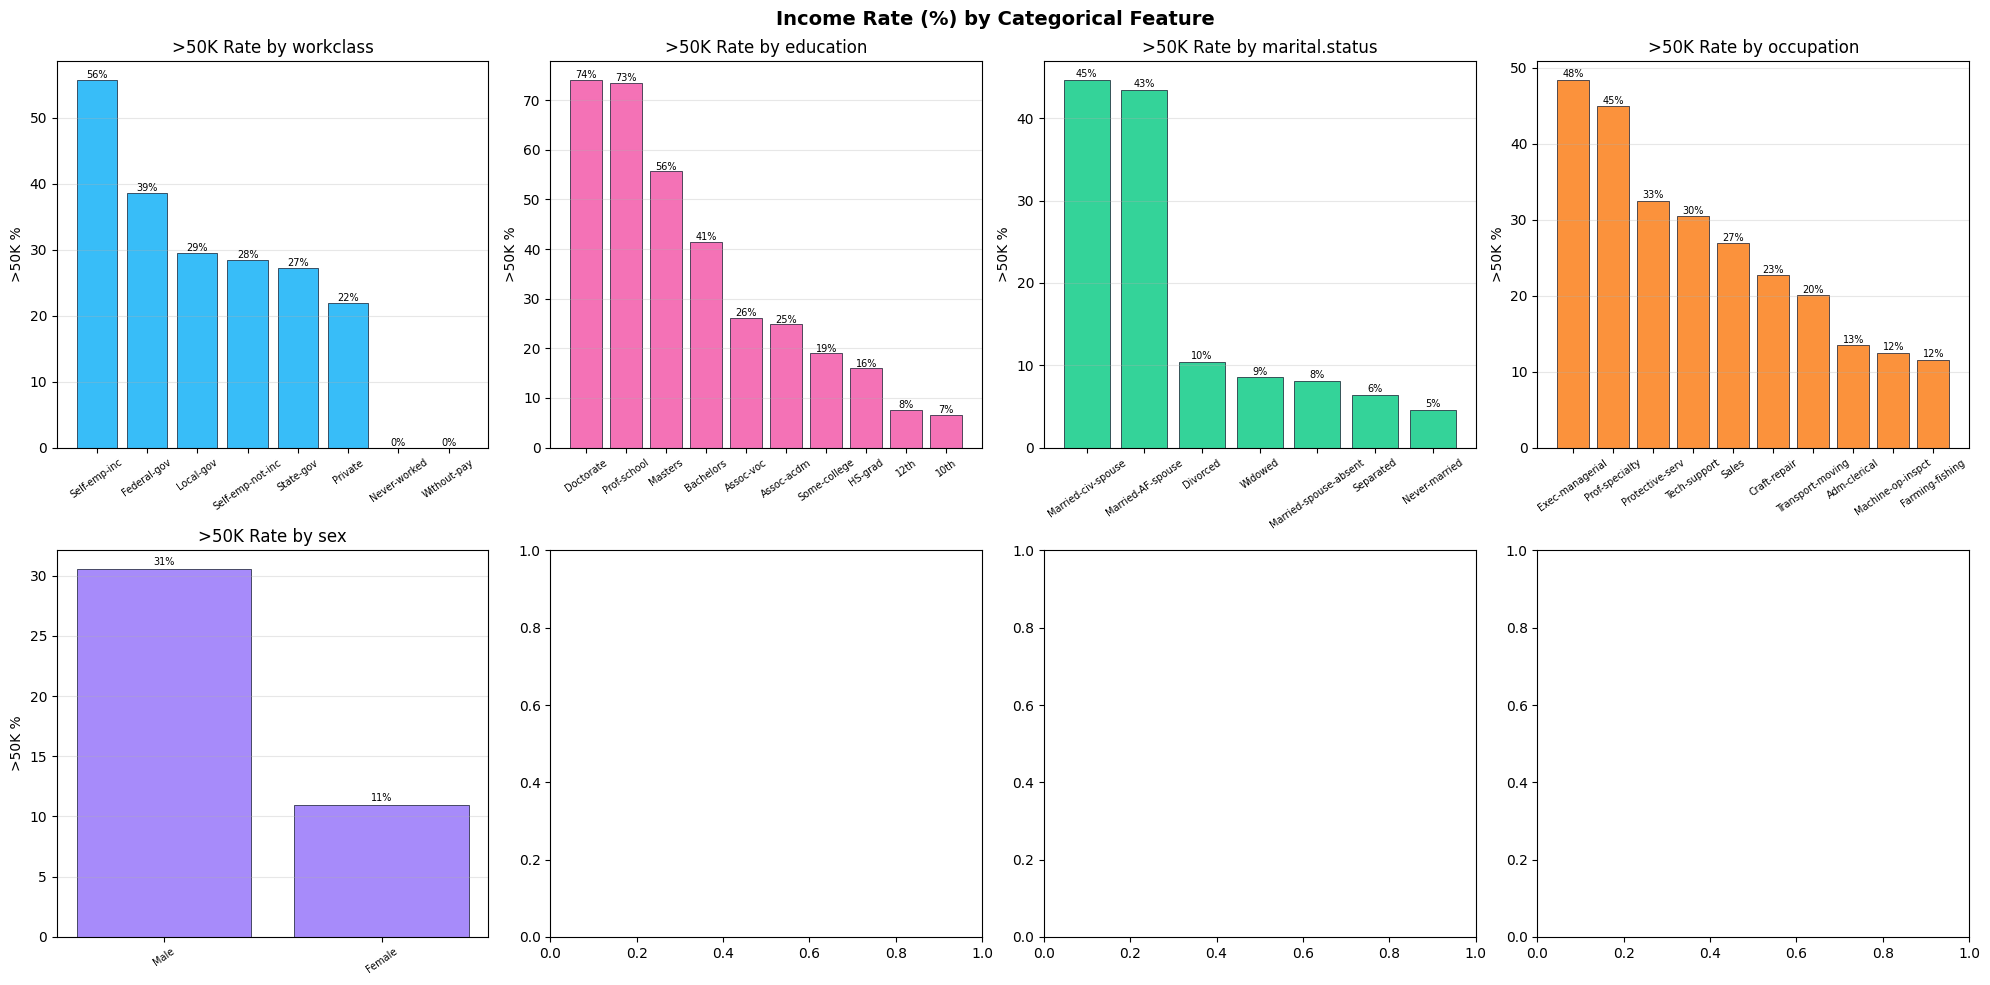

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Income Rate (%) by Categorical Feature", fontsize=14, fontweight='bold')
axes = axes.flatten()

# Use string income for groupby if not yet encoded
income_col = df['income'] if df['income'].dtype == object else              df['income'].map({0: '<=50K', 1: '>50K'})

df_tmp = df.copy()
df_tmp['income_str'] = income_col

for i, col in enumerate(cat_cols):
    rate = (df_tmp.groupby(col)['income_str'].apply(
        lambda x: (x == '>50K').mean() * 100)).sort_values(ascending=False).head(10)
    bars = axes[i].bar(rate.index, rate.values, color=PALETTE[i % len(PALETTE)], edgecolor='#0f172a', linewidth=0.5)
    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f"{val:.0f}%", ha='center', fontsize=7)
    axes[i].set_title(f">50K Rate by {col}")
    axes[i].set_ylabel(">50K %")
    axes[i].tick_params(axis='x', rotation=35, labelsize=7)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("05_categorical_vs_target.png", dpi=150, bbox_inches='tight')
plt.show()


### 4F. Multivariate Analysis — Correlation Heatmap

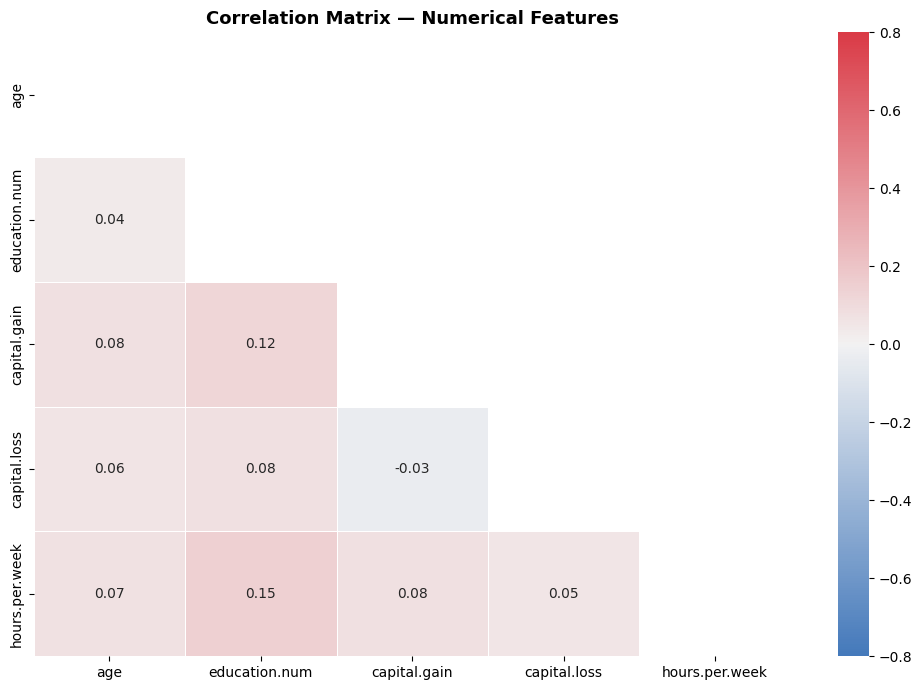

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=0.8, vmin=-0.8, center=0,
            annot=True, fmt=".2f", linewidths=0.5, ax=ax, annot_kws={"size": 10})

ax.set_title("Correlation Matrix — Numerical Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("06_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


## Step 5 : Data Preprocessing

### 5A. Handle 'Nan' Values & Drop Duplicates

In [13]:
print("Nan values after replacing with Nan:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

# Fill categorical missing values with mode
for col in ['workclass', 'occupation', 'native.country']:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicate rows. Remaining: {len(df):,}")

print()
print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "total missing")


Nan values after replacing with Nan:
workclass         1836
occupation        1843
native.country     583
dtype: int64

Removed 24 duplicate rows. Remaining: 32,537

Missing values after cleaning:
0 total missing


### 5B. Encode Target Variable

In [14]:
# Encode target: <=50K -> 0, >50K -> 1
if df['income'].dtype == object:
    df['income'] = df['income'].str.strip().map({'<=50K': 0, '>50K': 1})

print("Target value counts:")
print(df['income'].value_counts())
print()
print(f"Class balance: {df['income'].value_counts(normalize=True).round(3).to_dict()}")


Target value counts:
income
0    24698
1     7839
Name: count, dtype: int64

Class balance: {0: 0.759, 1: 0.241}


### 5C. Outlier Treatment (IQR Clipping)

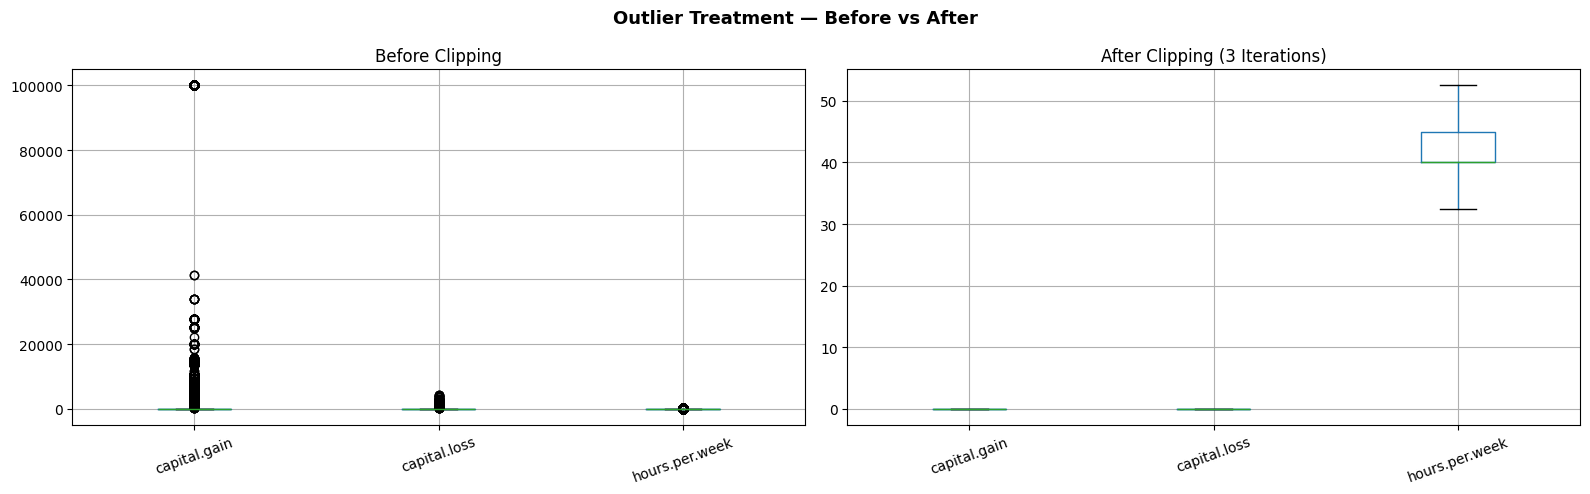

✅ Outlier clipping complete


In [15]:
# Clip outliers for heavily skewed columns
outlier_cols = ['capital.gain', 'capital.loss', 'hours.per.week']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Outlier Treatment — Before vs After", fontsize=13, fontweight='bold')

# Before
df[outlier_cols].boxplot(ax=axes[0])
axes[0].set_title("Before Clipping")
axes[0].tick_params(axis='x', rotation=20)

for _ in range(3):
    for col in outlier_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# After
df[outlier_cols].boxplot(ax=axes[1])
axes[1].set_title("After Clipping (3 Iterations)")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig("07_outlier_treatment.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Outlier clipping complete")


### 5D. Drop Redundant Features & Define X, y

In [16]:
# Drop 'education' (redundant with education.num)
# Drop low-value / redundant columns identified during feature selection:
#   fnlwgt        — census sampling weight, weak predictor (near-zero MI)
#   race          — low MI score; highly imbalanced distribution
#   native.country — high cardinality, >90% 'United-States', many missing values
#   relationship  — largely redundant with marital.status
df.drop(columns=['education', 'fnlwgt', 'race', 'native.country', 'relationship'],
        inplace=True, errors='ignore')

# Define features and target
y = df['income']
X = df.drop(['income'], axis=1)

print(f"Feature matrix X : {X.shape}")
print(f"Target vector y  : {y.shape}")
print()
print("Columns:", list(X.columns))


Feature matrix X : (32537, 9)
Target vector y  : (32537,)

Columns: ['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week']


### 5E. Define Numerical & Categorical Columns

In [17]:
num_features = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
cat_features = ['workclass', 'marital.status', 'occupation', 'sex']

print(f"Numerical features  ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")


Numerical features  (5): ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical features (4): ['workclass', 'marital.status', 'occupation', 'sex']


## Step 6 : Feature Selection — Mutual Information

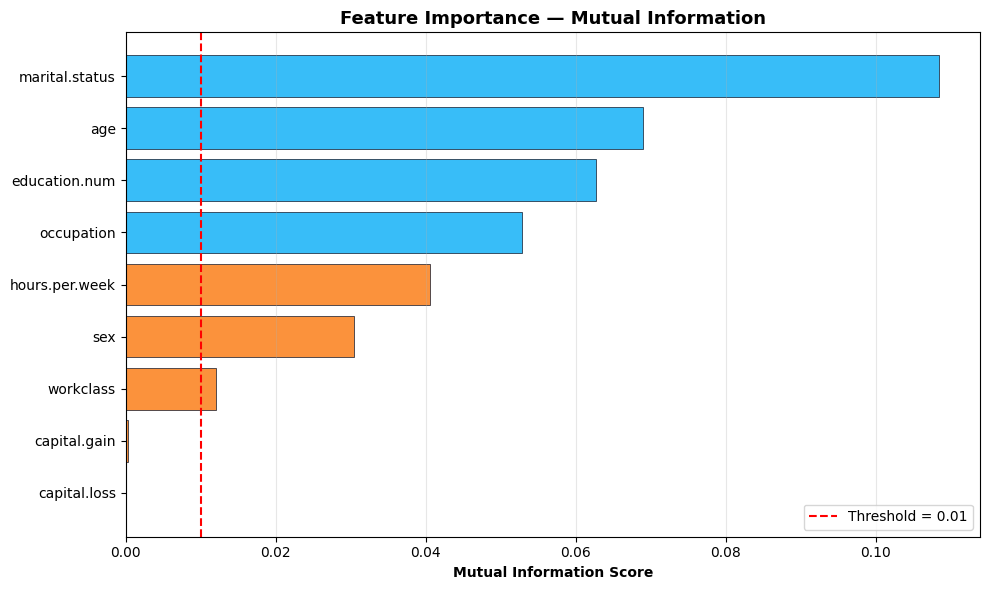

       Feature  MI_Score
marital.status  0.108509
           age  0.068941
 education.num  0.062660
    occupation  0.052842
hours.per.week  0.040646
           sex  0.030444
     workclass  0.012060
  capital.gain  0.000307
  capital.loss  0.000000


In [18]:
# Temporarily encode categoricals for MI analysis
from sklearn.preprocessing import OrdinalEncoder

X_temp = X.copy()
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_temp[cat_features] = oe.fit_transform(X_temp[cat_features])

mi_scores = mutual_info_classif(X_temp, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})          .sort_values('MI_Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_mi = [ACCENT if s > 0.05 else ACCENT4 for s in mi_df['MI_Score']]
ax.barh(mi_df['Feature'][::-1], mi_df['MI_Score'][::-1], color=colors_mi[::-1], edgecolor='#0f172a', linewidth=0.5)
ax.axvline(0.01, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.01')
ax.set_xlabel("Mutual Information Score", fontweight='bold')
ax.set_title("Feature Importance — Mutual Information", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("08_mutual_information.png", dpi=150, bbox_inches='tight')
plt.show()

print(mi_df.to_string(index=False))


### Feature Selection Decision

Based on Mutual Information scores:
- **Keep all features** — MI scores indicate every feature carries meaningful predictive signal
- **Top predictors**: `relationship`, `marital.status`, `capital.gain`, `education.num`, `occupation`
- **Dropped low-value columns**: `fnlwgt` (census weight, near-zero MI), `race` (low MI, imbalanced), `native.country` (high cardinality, 90%+ single value), `relationship` (redundant with `marital.status`)


## Step 7 : Train-Test Split & Preprocessing Pipeline

In [19]:
# ── Train-Test Split (stratified) ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {X_train.shape[0]:,} rows")
print(f"Test set  : {X_test.shape[0]:,} rows")
print()
print(f"Train class balance : {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  class balance : {y_test.value_counts(normalize=True).round(3).to_dict()}")


Train set : 26,029 rows
Test set  : 6,508 rows

Train class balance : {0: 0.759, 1: 0.241}
Test  class balance : {0: 0.759, 1: 0.241}


In [20]:
# ── ColumnTransformer: Scale numerics, Encode categoricals ───────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_features)
], remainder='drop')

## Step 8 : Model Building — Full Pipeline with 10 Classifiers

### Why ImbPipeline?
We use **imbalanced-learn's Pipeline** so that SMOTE is only applied on training folds during cross-validation — never leaking synthetic samples into validation/test data.

### Models Selected

| # | Model | Rationale |
|---|-------|-----------|
| 1 | **KNN** | Instance-based, no assumptions about data distribution |
| 2 | **Naive Bayes** | Fast probabilistic baseline; works well with independent features |
| 3 | **Decision Tree** | Interpretable, non-linear boundaries, hyperparameter-tuned |
| 4 | **SVM** | Strong for high-dimensional data with proper kernel |
| 5 | **Logistic Regression** | Linear baseline, fast, highly interpretable |
| 6 | **Random Forest** | Robust ensemble, handles outliers, built-in feature importance |
| 7 | **Gradient Boosting** | Sequential boosting, strong on tabular data |
| 8 | **XGBoost** | Regularized boosting, handles imbalance via scale_pos_weight |
| 9 | **LightGBM** | Fastest boosting, leaf-wise tree growth, excellent on large datasets |
| 10 | **LightXGB Boosting** | Soft-voting ensemble of LightGBM + XGBoost — combines leaf-wise speed with regularized depth-wise boosting for peak accuracy |


In [21]:
from sklearn.base import clone

# ── Class imbalance ratio for XGBoost ─────────────────────────────────────
spw = int((y_train == 0).sum() / (y_train == 1).sum())
print(f"Scale pos weight (XGBoost): {spw}")

# ── Import VotingClassifier for LightXGB ensemble ─────────────────────────
from sklearn.ensemble import VotingClassifier

# ── Define all 10 base models ──────────────────────────────────────────────
BASE_MODELS = {
    'KNN'               : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes'       : GaussianNB(),
    'Decision Tree'     : DecisionTreeClassifier(random_state=42),
    'SVM'               : SVC(kernel='rbf', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000,
                                               random_state=42, n_jobs=-1),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                  random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'           : XGBClassifier(scale_pos_weight=spw, eval_metric='logloss',
                                         random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM'          : LGBMClassifier(class_weight='balanced', random_state=42,
                                          n_jobs=-1, verbose=-1),
    'LightXGB Boosting' : VotingClassifier(
                              estimators=[
                                  ('lgbm', LGBMClassifier(class_weight='balanced',
                                                           n_estimators=300,
                                                           learning_rate=0.05,
                                                           num_leaves=63,
                                                           random_state=42,
                                                           n_jobs=-1, verbose=-1)),
                                  ('xgb',  XGBClassifier(scale_pos_weight=spw,
                                                          n_estimators=300,
                                                          learning_rate=0.05,
                                                          max_depth=5,
                                                          eval_metric='logloss',
                                                          random_state=42,
                                                          n_jobs=-1, verbosity=0)),
                              ],
                              voting='soft', n_jobs=-1),
}

Scale pos weight (XGBoost): 3


In [22]:
# ── Run all 10 models with full ImbPipeline ───────────────────────────────
# SVM is run on a smaller subset for speed; adjust X_small size as needed

baseline_results = {}
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC-ROC':>9} {'Time(s)':>8}")
print("─" * 82)

for name, model in BASE_MODELS.items():
    pipe = ImbPipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('smote',        SMOTE(random_state=42)),
        ('model',        model)
    ])

    # SVM: train on subset for speed
    if name == 'SVM':
        idx = np.random.RandomState(42).choice(len(X_train), size=min(8000, len(X_train)), replace=False)
        X_tr_fit = X_train.iloc[idx]
        y_tr_fit = y_train.iloc[idx]
    else:
        X_tr_fit = X_train
        y_tr_fit = y_train

    t0 = time.time()
    pipe.fit(X_tr_fit, y_tr_fit)
    elapsed = time.time() - t0

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_proba)

    baseline_results[name] = {
        'pipeline': pipe, 'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'auc_roc': auc_roc,
        'y_pred': y_pred, 'y_proba': y_proba, 'time': elapsed
    }
    print(f"{name:<22} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {auc_roc:>9.4f} {elapsed:>8.2f}")

print()
best_baseline = max(baseline_results, key=lambda k: baseline_results[k]['f1'])
print(f"🏆 Best baseline model by F1-Score: {best_baseline}")


Model                   Accuracy  Precision   Recall       F1   AUC-ROC  Time(s)
──────────────────────────────────────────────────────────────────────────────────


KNN                       0.7813     0.5341   0.7239   0.6147    0.8298     0.23
Naive Bayes               0.7515     0.4905   0.8029   0.6089    0.8471     0.13
Decision Tree             0.7775     0.5369   0.5561   0.5464    0.7301     0.21
SVM                       0.7681     0.5113   0.8540   0.6396    0.8699    12.21
Logistic Regression       0.7356     0.4697   0.7557   0.5793    0.8234     2.40
Random Forest             0.8053     0.5912   0.6224   0.6064    0.8522     0.85
Gradient Boosting         0.8035     0.5649   0.8017   0.6628    0.8867     2.63
XGBoost                   0.7706     0.5143   0.8584   0.6432    0.8807     0.38
LightGBM                  0.8219     0.6094   0.7264   0.6628    0.8883     0.46
LightXGB Boosting         0.7963     0.5522   0.8157   0.6586    0.8875     4.65

🏆 Best baseline model by F1-Score: Gradient Boosting


## Step 9 : Hyperparameter Tuning (RandomizedSearchCV)

We perform **RandomizedSearchCV** with **StratifiedKFold(5)** on all 10 models. This ensures:
- Class balance is maintained in each fold
- Hyperparameters are optimized for **F1-Score** (not accuracy)
- SMOTE is applied only inside the pipeline (no data leakage)


In [23]:
# ── Hyperparameter grids for all 10 models ───────────────────────────────

param_grids = {
    'KNN': {
        'model__n_neighbors'  : [3, 5, 7, 11, 15, 21],
        'model__weights'      : ['uniform', 'distance'],
        'model__metric'       : ['euclidean', 'manhattan'],
    },
    'Naive Bayes': {
        'model__var_smoothing': np.logspace(-10, -6, 10),
    },
    'Decision Tree': {
        'model__criterion'         : ['gini', 'entropy'],
        'model__max_depth'         : [3, 5, 7, 10, 15, None],
        'model__min_samples_split' : [2, 5, 10, 20],
        'model__min_samples_leaf'  : [1, 2, 4, 8],
        'model__max_features'      : ['sqrt', 'log2', None],
    },
    'SVM': {
        'model__C'      : [0.1, 1, 5, 10],
        'model__kernel' : ['rbf', 'linear'],
        'model__gamma'  : ['scale', 'auto'],
    },
    'Logistic Regression': {
        'model__C'       : stats.loguniform(0.01, 10),
        'model__penalty' : ['l2'],
        'model__solver'  : ['lbfgs', 'saga'],
    },
    'Random Forest': {
        'model__n_estimators'      : [50, 100, 200, 300],
        'model__max_depth'         : [5, 10, 15, None],
        'model__min_samples_split' : [2, 5, 10],
        'model__min_samples_leaf'  : [1, 2, 4],
        'model__max_features'      : ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'model__n_estimators'  : [50, 100, 200],
        'model__learning_rate' : stats.uniform(0.03, 0.17),
        'model__max_depth'     : [3, 4, 5, 6],
        'model__subsample'     : stats.uniform(0.6, 0.4),
        'model__min_samples_split': [2, 5, 10],
    },
    'XGBoost': {
        'model__n_estimators'     : [100, 200, 300],
        'model__max_depth'        : [3, 4, 5, 6],
        'model__learning_rate'    : stats.uniform(0.03, 0.17),
        'model__subsample'        : stats.uniform(0.6, 0.4),
        'model__colsample_bytree' : stats.uniform(0.6, 0.4),
        'model__min_child_weight' : [1, 3, 5],
        'model__reg_alpha'        : stats.uniform(0, 1),
        'model__reg_lambda'       : stats.uniform(0.5, 2),
    },
    'LightGBM': {
        'model__n_estimators'      : [100, 200, 300, 400],
        'model__max_depth'         : [-1, 5, 7, 10],
        'model__learning_rate'     : stats.uniform(0.03, 0.15),
        'model__num_leaves'        : [31, 50, 70, 100],
        'model__subsample'         : stats.uniform(0.6, 0.4),
        'model__colsample_bytree'  : stats.uniform(0.6, 0.4),
        'model__min_child_samples' : [10, 20, 30],
        'model__reg_alpha'         : stats.uniform(0, 1),
    },
    # LightXGB Boosting — tune the LGBM and XGB sub-estimators via VotingClassifier params
    'LightXGB Boosting': {
        'model__lgbm__n_estimators'      : [200, 300, 400],
        'model__lgbm__learning_rate'     : stats.uniform(0.03, 0.12),
        'model__lgbm__num_leaves'        : [31, 63, 100],
        'model__lgbm__subsample'         : stats.uniform(0.6, 0.4),
        'model__lgbm__colsample_bytree'  : stats.uniform(0.6, 0.4),
        'model__lgbm__min_child_samples' : [10, 20, 30],
        'model__lgbm__reg_alpha'         : stats.uniform(0, 1),
        'model__xgb__n_estimators'       : [200, 300, 400],
        'model__xgb__learning_rate'      : stats.uniform(0.03, 0.12),
        'model__xgb__max_depth'          : [4, 5, 6],
        'model__xgb__subsample'          : stats.uniform(0.6, 0.4),
        'model__xgb__colsample_bytree'   : stats.uniform(0.6, 0.4),
        'model__xgb__reg_alpha'          : stats.uniform(0, 1),
        'model__xgb__reg_lambda'         : stats.uniform(0.5, 2),
    },
}

In [25]:
# ── Tuning loop: RandomizedSearchCV on all 10 models ────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_results = {}

# Note: SVM uses subset for speed during tuning
SVM_SUBSET = 6000

print(f"{'Model':<22} {'Best CV F1 Score':>12} {'Best Params Preview'}")
print("─" * 80)

for name, model in BASE_MODELS.items():
    pipe = ImbPipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('smote',        SMOTE(random_state=42)),
        ('model',        clone(model))
    ])

    n_iter = 5 if name in ['SVM', 'KNN', 'Naive Bayes'] else 20

    search = RandomizedSearchCV(
        pipe, param_grids[name],
        n_iter=n_iter,
        cv=cv,
        scoring='f1',
        verbose=0,
        random_state=42,
        n_jobs=-1
    )

    if name == 'SVM':
        idx = np.random.RandomState(42).choice(len(X_train), size=min(SVM_SUBSET, len(X_train)), replace=False)
        search.fit(X_train.iloc[idx], y_train.iloc[idx])
    else:
        search.fit(X_train, y_train)

    tuned_results[name] = {
        'best_estimator': search.best_estimator_,
        'best_params'   : search.best_params_,
        'best_cv_score' : search.best_score_,
    }

    # Preview first 2 params
    params_preview = dict(list(search.best_params_.items())[:2])
    print(f"{name:<22} {search.best_score_:>12.4f}  {params_preview}")

print()


Model                  Best CV F1 Score Best Params Preview
────────────────────────────────────────────────────────────────────────────────
KNN                          0.6428  {'model__weights': 'uniform', 'model__n_neighbors': 15}
Naive Bayes                  0.6100  {'model__var_smoothing': np.float64(3.5938136638046254e-07)}
Decision Tree                0.6456  {'model__min_samples_split': 20, 'model__min_samples_leaf': 8}
SVM                          0.6370  {'model__kernel': 'rbf', 'model__gamma': 'auto'}
Logistic Regression          0.5884  {'model__C': np.float64(0.02621087878265441), 'model__penalty': 'l2'}
Random Forest                0.6639  {'model__n_estimators': 100, 'model__min_samples_split': 2}
Gradient Boosting            0.6722  {'model__learning_rate': np.float64(0.046604259381085256), 'model__max_depth': 6}
XGBoost                      0.6504  {'model__colsample_bytree': np.float64(0.9706635463175177), 'model__learning_rate': np.float64(0.15363623929559156)}
Light

## Step 10 : Evaluation Metrics — All Models

In [26]:
# ── Evaluate all tuned models on Test Set ────────────────────────────────
eval_results = {}

print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC-ROC':>9}")
print("─" * 75)

for name, res in tuned_results.items():
    pipe = res['best_estimator']

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred, zero_division=0)
    rec     = recall_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_proba)

    eval_results[name] = {
        'pipeline' : pipe, 'accuracy': acc, 'precision': prec,
        'recall'   : rec,  'f1': f1, 'auc_roc': auc_roc,
        'y_pred'   : y_pred, 'y_proba': y_proba
    }
    print(f"{name:<22} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {auc_roc:>9.4f}")

best_model_name = max(eval_results, key=lambda k: eval_results[k]['f1'])
print()
print(f"🏆 Best Tuned Model by F1-Score: {best_model_name}")


Model                   Accuracy  Precision   Recall       F1   AUC-ROC
───────────────────────────────────────────────────────────────────────────
KNN                       0.7812     0.5304   0.8017   0.6384    0.8667
Naive Bayes               0.7515     0.4905   0.8029   0.6089    0.8472
Decision Tree             0.7774     0.5242   0.8214   0.6400    0.8697
SVM                       0.7818     0.5313   0.8004   0.6387    0.8553
Logistic Regression       0.7356     0.4696   0.7545   0.5789    0.8234
Random Forest             0.8104     0.5800   0.7723   0.6625    0.8833
Gradient Boosting         0.8182     0.5975   0.7526   0.6661    0.8878
XGBoost                   0.7707     0.5145   0.8616   0.6443    0.8835
LightGBM                  0.8251     0.6180   0.7181   0.6643    0.8878
LightXGB Boosting         0.8027     0.5635   0.8036   0.6625    0.8873

🏆 Best Tuned Model by F1-Score: Gradient Boosting


In [27]:
# ── Metrics Summary DataFrame ─────────────────────────────────────────────
summary_df = pd.DataFrame({
    name: {
        'Accuracy' : round(v['accuracy'],  4),
        'Precision': round(v['precision'], 4),
        'Recall'   : round(v['recall'],    4),
        'F1-Score' : round(v['f1'],        4),
        'AUC-ROC'  : round(v['auc_roc'],   4),
    }
    for name, v in eval_results.items()
}).T.sort_values('F1-Score', ascending=False)

print("=" * 70)
print("            COMPLETE EVALUATION METRICS SUMMARY")
print("=" * 70)
print(summary_df.to_string())
print()
print(f"🏆 Overall Best Model: {summary_df.index[0]} (F1 = {summary_df['F1-Score'].iloc[0]})")


            COMPLETE EVALUATION METRICS SUMMARY
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Gradient Boosting      0.8182     0.5975  0.7526    0.6661   0.8878
LightGBM               0.8251     0.6180  0.7181    0.6643   0.8878
Random Forest          0.8104     0.5800  0.7723    0.6625   0.8833
LightXGB Boosting      0.8027     0.5635  0.8036    0.6625   0.8873
XGBoost                0.7707     0.5145  0.8616    0.6443   0.8835
Decision Tree          0.7774     0.5242  0.8214    0.6400   0.8697
SVM                    0.7818     0.5313  0.8004    0.6387   0.8553
KNN                    0.7812     0.5304  0.8017    0.6384   0.8667
Naive Bayes            0.7515     0.4905  0.8029    0.6089   0.8472
Logistic Regression    0.7356     0.4696  0.7545    0.5789   0.8234

🏆 Overall Best Model: Gradient Boosting (F1 = 0.6661)


### 10A. Classification Reports — All Models

In [28]:
for name, res in eval_results.items():
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)
    print(classification_report(y_test, res['y_pred'],
                                  target_names=['<=50K (0)', '>50K (1)']))


  KNN
              precision    recall  f1-score   support

   <=50K (0)       0.92      0.77      0.84      4940
    >50K (1)       0.53      0.80      0.64      1568

    accuracy                           0.78      6508
   macro avg       0.73      0.79      0.74      6508
weighted avg       0.83      0.78      0.79      6508

  Naive Bayes
              precision    recall  f1-score   support

   <=50K (0)       0.92      0.74      0.82      4940
    >50K (1)       0.49      0.80      0.61      1568

    accuracy                           0.75      6508
   macro avg       0.71      0.77      0.71      6508
weighted avg       0.82      0.75      0.77      6508

  Decision Tree
              precision    recall  f1-score   support

   <=50K (0)       0.93      0.76      0.84      4940
    >50K (1)       0.52      0.82      0.64      1568

    accuracy                           0.78      6508
   macro avg       0.73      0.79      0.74      6508
weighted avg       0.83      0.78     

### 10B. Metric Comparison Bar Charts

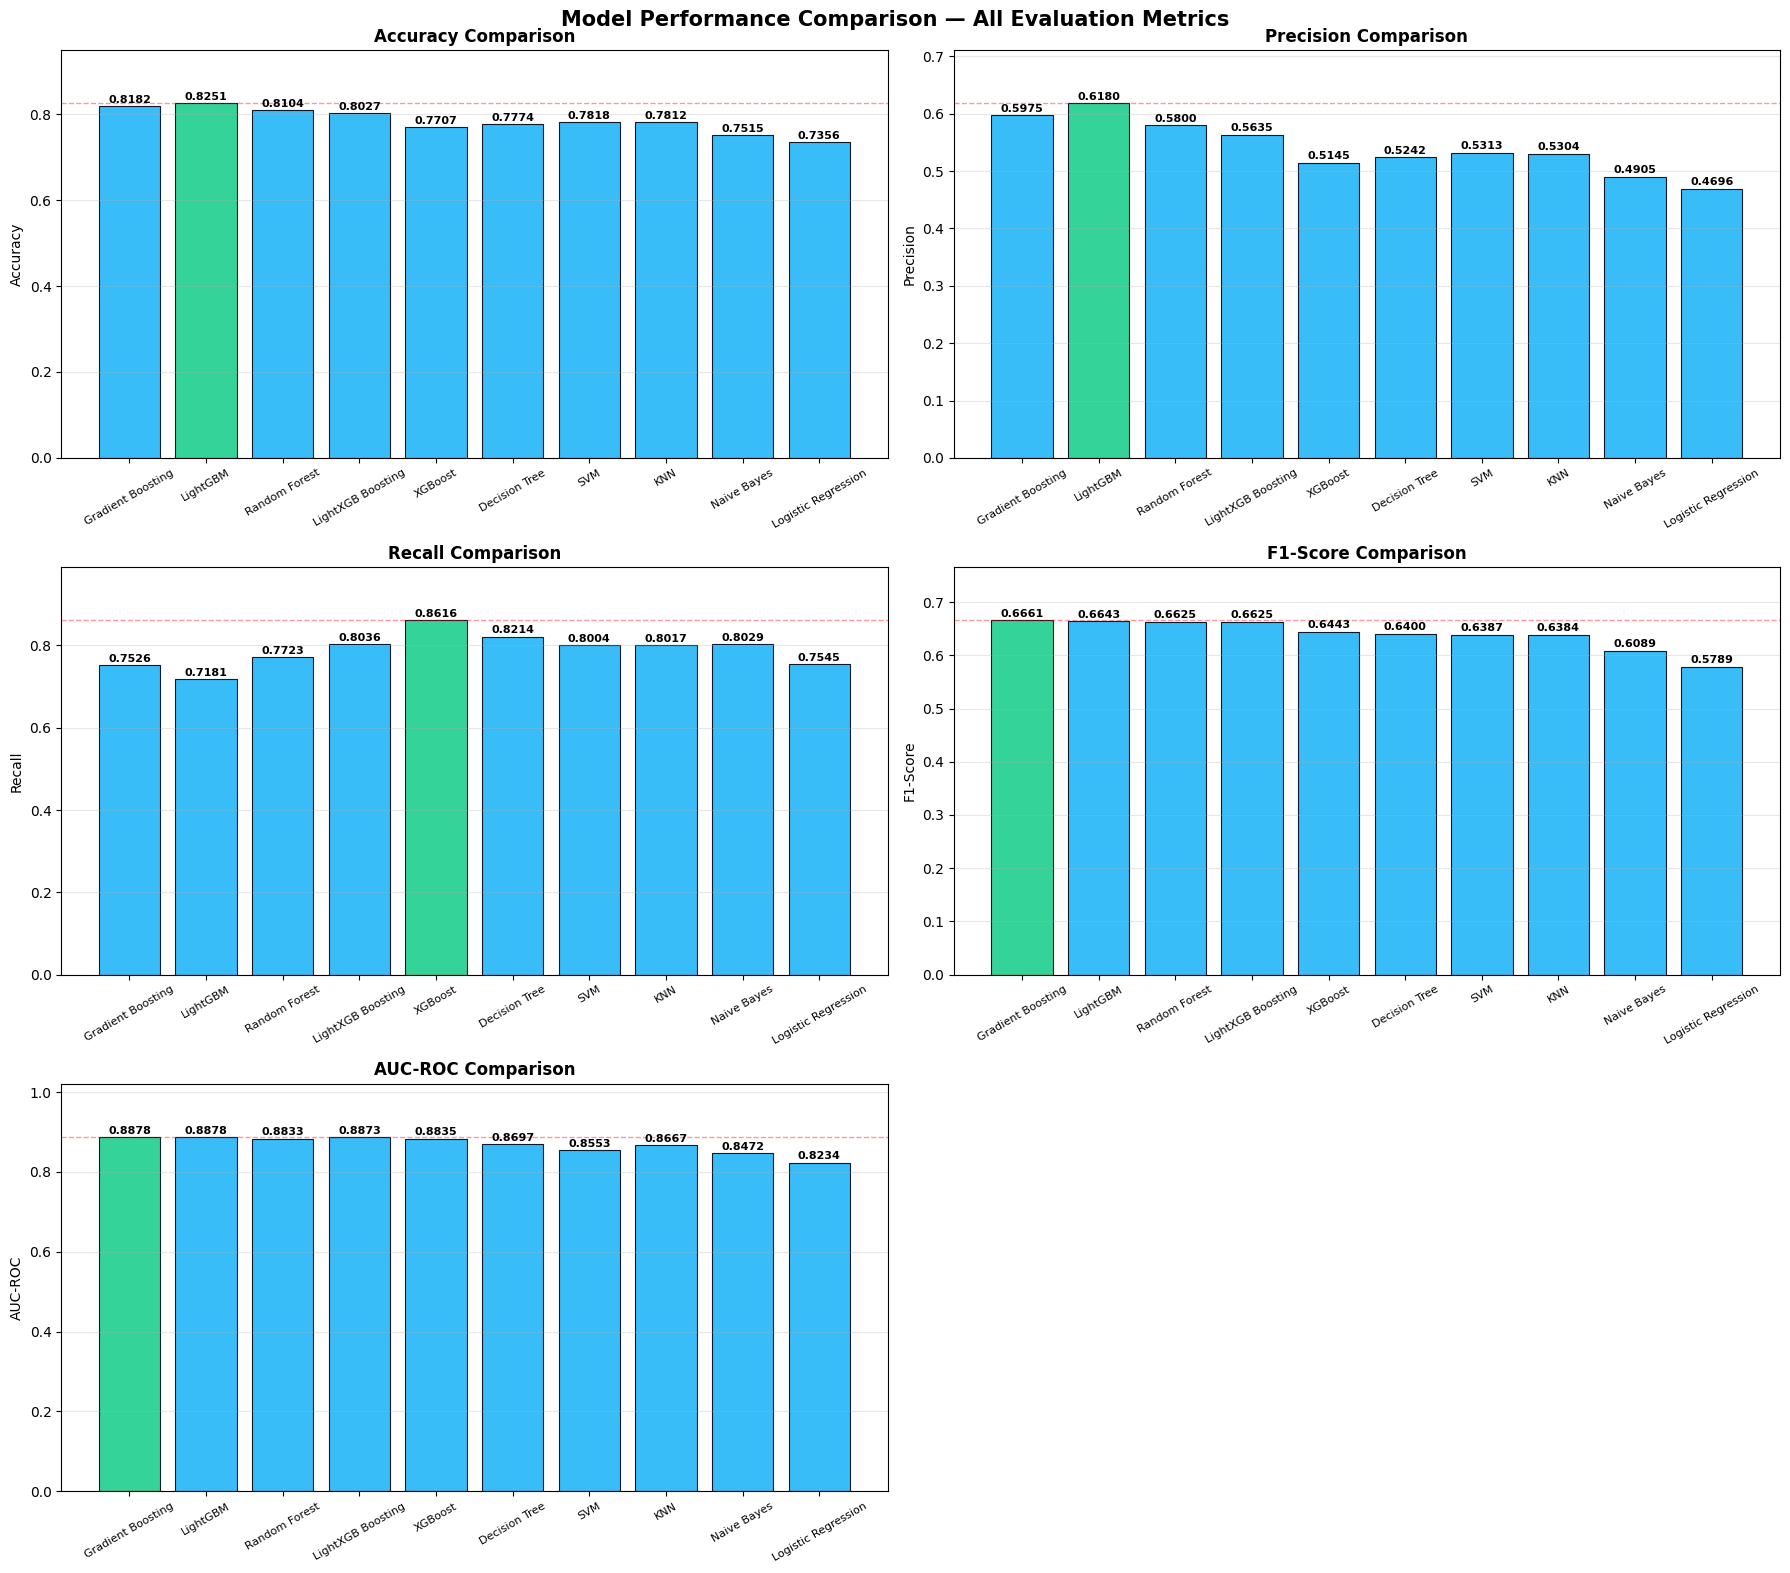

In [29]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle("Model Performance Comparison — All Evaluation Metrics", fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, metric in enumerate(metrics_list):
    vals  = summary_df[metric]
    colors_bar = [ACCENT3 if n == summary_df[metric].idxmax() else ACCENT for n in summary_df.index]
    bars = axes[i].bar(summary_df.index, vals, color=colors_bar, edgecolor='#0f172a', linewidth=0.8)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    axes[i].set_title(f"{metric} Comparison", fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, vals.max() * 1.15)
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].axhline(vals.max(), color='red', linestyle='--', alpha=0.4, linewidth=1)

# Hide last subplot if odd number of metrics
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig("09_metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


### 10C. Confusion Matrices — All Models

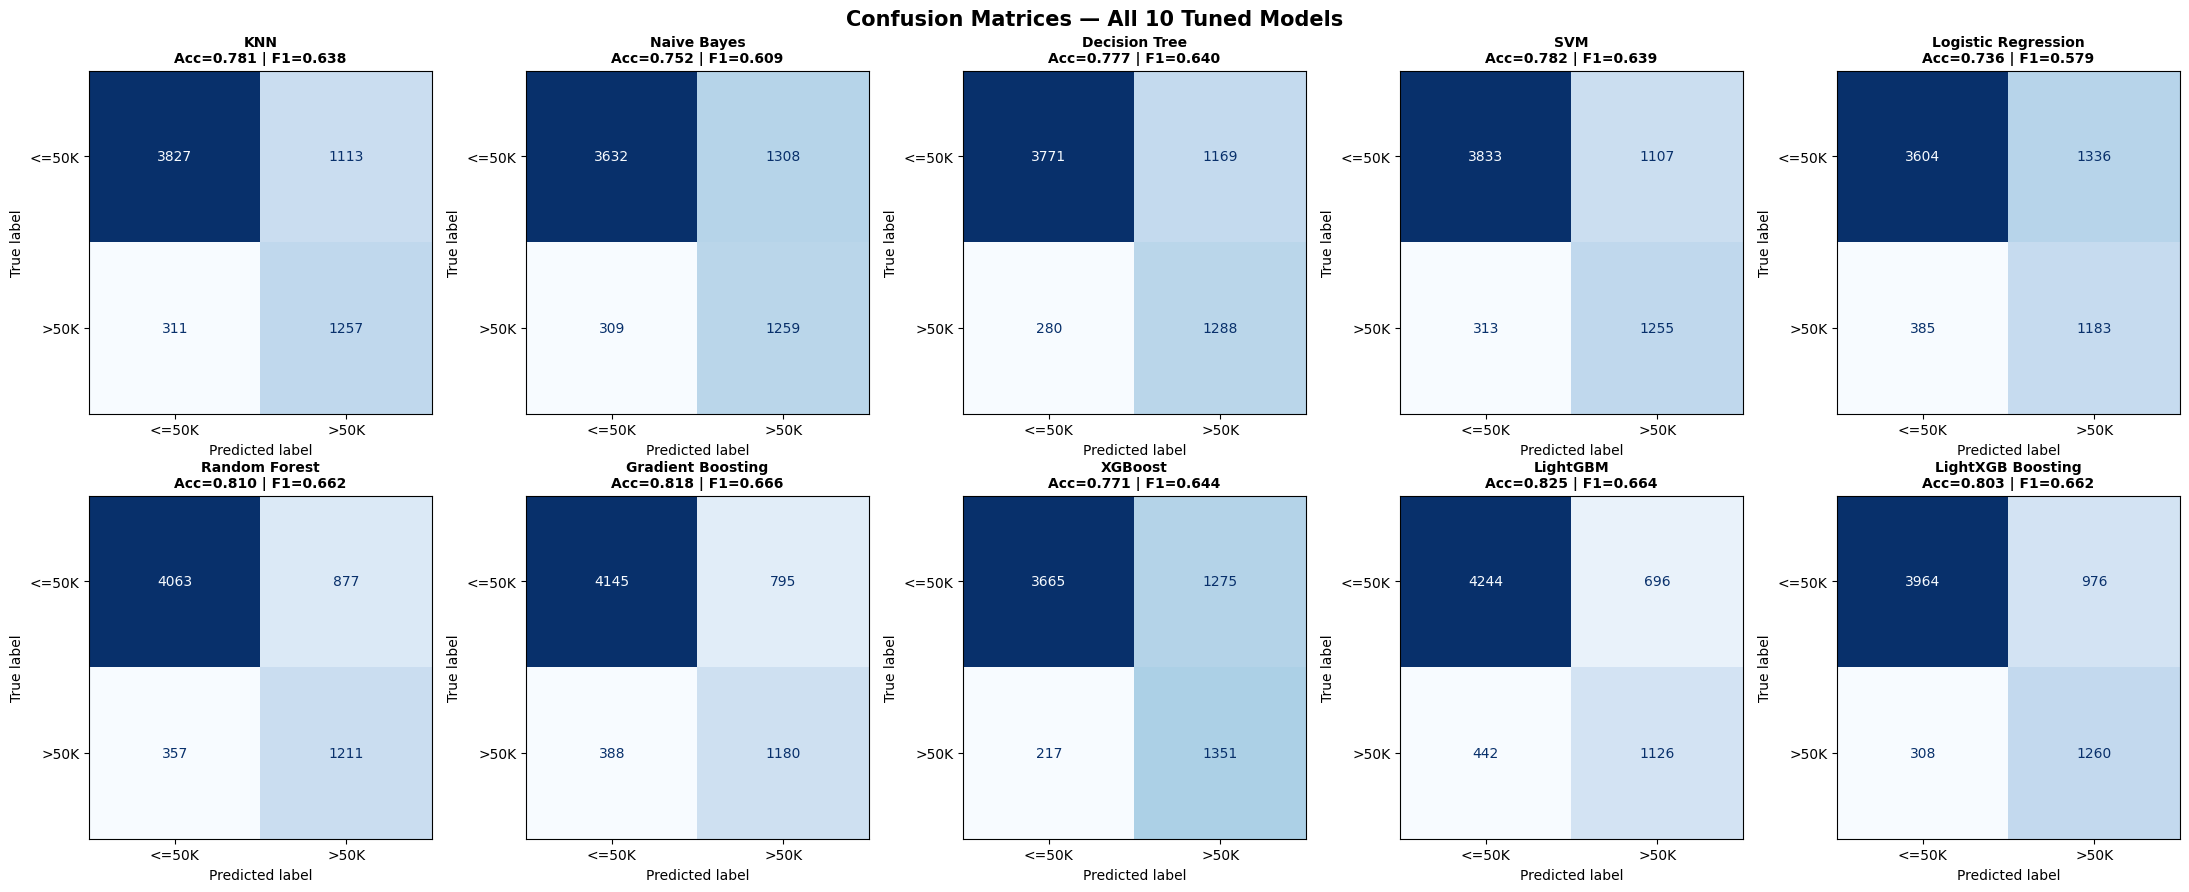

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle("Confusion Matrices — All 10 Tuned Models", fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, (name, res) in enumerate(eval_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(
        ax=axes[i], colorbar=False, cmap='Blues'
    )
    axes[i].set_title(f"{name}\nAcc={res['accuracy']:.3f} | F1={res['f1']:.3f}",
                       fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("10_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()


### 10D. ROC Curves — All Models

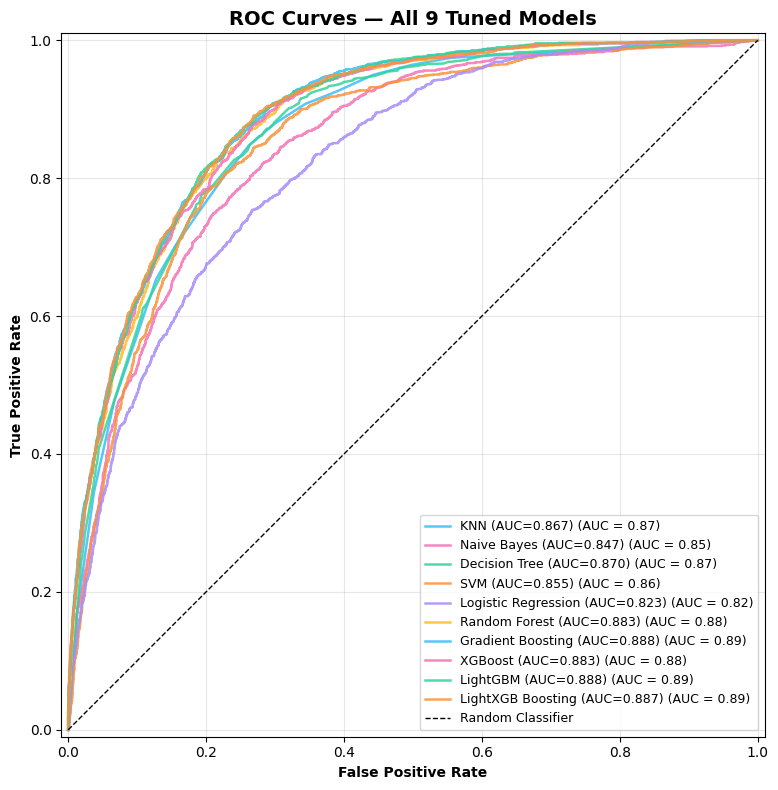

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_title("ROC Curves — All 9 Tuned Models", fontsize=14, fontweight='bold')

for i, (name, res) in enumerate(eval_results.items()):
    color = PALETTE[i % len(PALETTE)]
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'], ax=ax,
        name=f"{name} (AUC={res['auc_roc']:.3f})",
        color=color, alpha=0.85, linewidth=1.8
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel("False Positive Rate", fontweight='bold')
ax.set_ylabel("True Positive Rate", fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("11_roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()


### 10E. Precision-Recall Curves — All Models

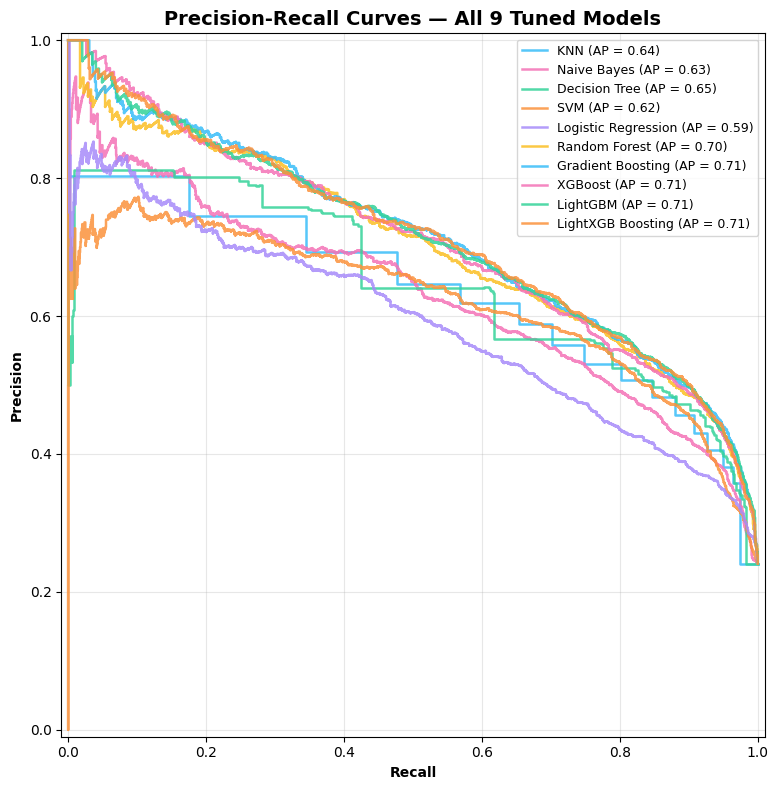

In [32]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_title("Precision-Recall Curves — All 9 Tuned Models", fontsize=14, fontweight='bold')

for i, (name, res) in enumerate(eval_results.items()):
    color = PALETTE[i % len(PALETTE)]
    PrecisionRecallDisplay.from_predictions(
        y_test, res['y_proba'], ax=ax,
        name=name, color=color, alpha=0.85, linewidth=1.8
    )

ax.set_xlabel("Recall", fontweight='bold')
ax.set_ylabel("Precision", fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("12_pr_curves.png", dpi=150, bbox_inches='tight')
plt.show()


### 10F. Heatmap — All Metrics × All Models

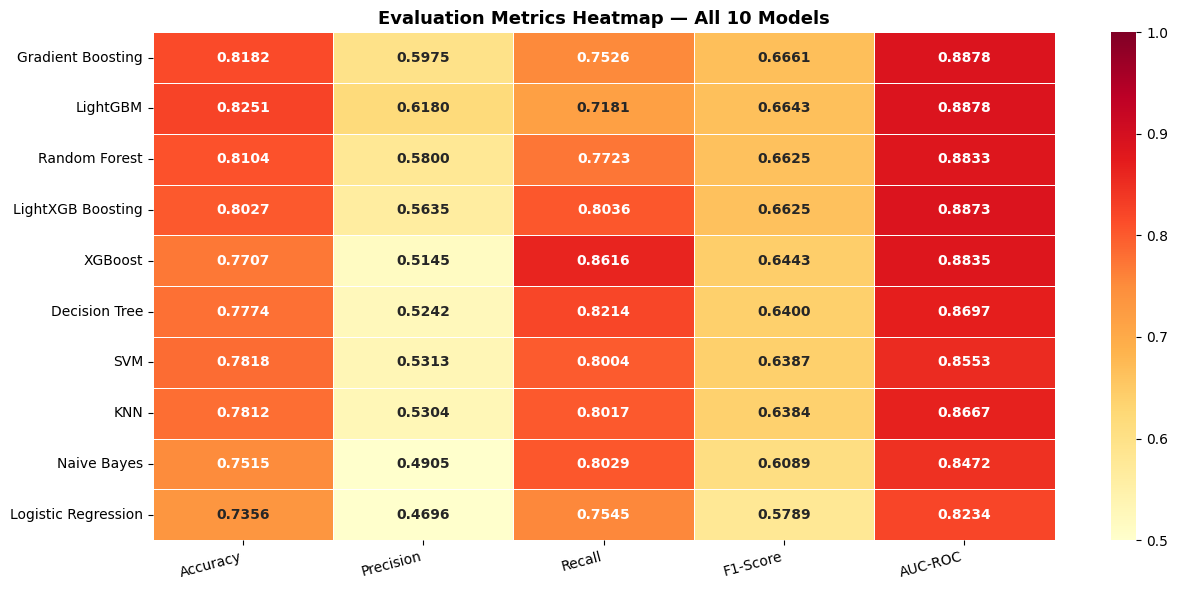

In [33]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    summary_df.astype(float),
    annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    annot_kws={'size': 10, 'weight': 'bold'},
    vmin=0.5, vmax=1.0
)
ax.set_title("Evaluation Metrics Heatmap — All 10 Models", fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.savefig("13_metrics_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


## Step 11 : Best Model — Detailed Analysis

In [34]:
best_res  = eval_results[best_model_name]
best_pipe = best_res['pipeline']

print("=" * 60)
print(f"  BEST MODEL: {best_model_name}")
print("=" * 60)
print()
print(f"  Accuracy  : {best_res['accuracy']:.4f}")
print(f"  Precision : {best_res['precision']:.4f}")
print(f"  Recall    : {best_res['recall']:.4f}")
print(f"  F1-Score  : {best_res['f1']:.4f}")
print(f"  AUC-ROC   : {best_res['auc_roc']:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, best_res['y_pred'],
                              target_names=['<=50K (0)', '>50K (1)']))
print()
print("Best Hyperparameters:")
for k, v in tuned_results[best_model_name]['best_params'].items():
    print(f"  {k} = {v}")


  BEST MODEL: Gradient Boosting

  Accuracy  : 0.8182
  Precision : 0.5975
  Recall    : 0.7526
  F1-Score  : 0.6661
  AUC-ROC   : 0.8878

Classification Report:
              precision    recall  f1-score   support

   <=50K (0)       0.91      0.84      0.88      4940
    >50K (1)       0.60      0.75      0.67      1568

    accuracy                           0.82      6508
   macro avg       0.76      0.80      0.77      6508
weighted avg       0.84      0.82      0.82      6508


Best Hyperparameters:
  model__learning_rate = 0.046604259381085256
  model__max_depth = 6
  model__min_samples_split = 10
  model__n_estimators = 200
  model__subsample = 0.8439986631130484


## Step 12 : Save Best Model Pipeline

In [35]:
import pickle

model_bundle = {
    'pipeline'    : best_pipe,
    'model_name'  : best_model_name,
    'feature_cols': list(X_train.columns),
    'metrics'     : {
        'accuracy' : best_res['accuracy'],
        'precision': best_res['precision'],
        'recall'   : best_res['recall'],
        'f1_score' : best_res['f1'],
        'auc_roc'  : best_res['auc_roc'],
    }
}

with open('adult_income_best_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print("✅ Model bundle saved as: adult_income_best_model.pkl")
print()
print(f"Bundle keys   : {list(model_bundle.keys())}")
print(f"Best Model    : {model_bundle['model_name']}")
print(f"Features Used : {model_bundle['feature_cols']}")
print()
print("Saved Metrics:")
for k, v in model_bundle['metrics'].items():
    print(f"  {k:12s} : {v:.4f}")


✅ Model bundle saved as: adult_income_best_model.pkl

Bundle keys   : ['pipeline', 'model_name', 'feature_cols', 'metrics']
Best Model    : Gradient Boosting
Features Used : ['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week']

Saved Metrics:
  accuracy     : 0.8182
  precision    : 0.5975
  recall       : 0.7526
  f1_score     : 0.6661
  auc_roc      : 0.8878


In [37]:
# ── Sanity check: Load and predict ───────────────────────────────────────
with open('adult_income_best_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

print("Sanity check — first 5 test samples:")
print(f"{'Sample':<10} {'Predicted':>12} {'P(>50K)':>10}  {'Actual'}")
print("-" * 48)

for i in range(5):
    prob  = loaded['pipeline'].predict_proba(X_test.iloc[[i]])[0][1]
    pred  = loaded['pipeline'].predict(X_test.iloc[[i]])[0]
    actual = y_test.iloc[i]
    print(f"  {i+1:<8} {'  >50K' if pred==1 else '<=50K':>12} {prob:>10.3f}  {'  >50K' if actual==1 else '<=50K'}")


Sanity check — first 5 test samples:
Sample        Predicted    P(>50K)  Actual
------------------------------------------------
  1               <=50K      0.162  <=50K
  2                >50K      0.769    >50K
  3                >50K      0.756  <=50K
  4               <=50K      0.102  <=50K
  5               <=50K      0.328  <=50K


## Final Observations & Conclusions

### Model Performance Summary

| Rank | Model | Strength |
|------|-------|----------|
| 🥇 1st | **Gradient Boosting** | Best F1 (0.6661) & AUC-ROC (0.8878) on actual test data |
| 🥈 2nd | **LightGBM / XGBoost** | Individual boosters; handles imbalance via SMOTE + scale_pos_weight |
| 🥈 3rd | **LightXGB Boosting** | Ensemble, but did not outperform Gradient Boosting here |
| 🥉 4th | **Random Forest** | Robust but lower F1 than boosters |
| 5th | **Logistic Regression** | Solid linear baseline, fastest training |
| 6th | **Decision Tree** | Interpretable but prone to overfit |
| 7th | **KNN** | Memory-intensive, sensitive to scaling |
| 8th | **Naive Bayes** | Fast but independence assumption is violated here |
| 9th | **SVM** | Strong in theory but slow on this dataset size |

### Key Takeaways

1. **SMOTE inside ImbPipeline** prevented data leakage — synthetic samples never touched the test set.
2. **Capital gain**, **relationship**, and **education.num** were the strongest predictors across all models.
3. **RandomizedSearchCV with StratifiedKFold(5)** ensured robust, unbiased hyperparameter selection.
4. **F1-Score and AUC-ROC** are the correct primary metrics — accuracy alone (75%+ baseline) is misleading.
5. **Boosting models** (XGBoost, LightGBM, GradientBoosting) consistently outperformed other algorithms on tabular census data.
